### Heating Rate Analysis
2026-07-28

Aim is to vastly simplify the current analysis of circa 2024 data.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import os
from scipy.optimize import curve_fit
from scipy.constants import h, hbar, pi, k as k_B

# paths
import sys
from pathlib import Path

notebook_dir = Path.cwd()
parent_dir = notebook_dir.parent
analysis_dir = parent_dir / "analysis"

if str(parent_dir) not in sys.path:
    sys.path.append(str(parent_dir))

if str(analysis_dir) not in sys.path:
    sys.path.append(str(analysis_dir))

from analysis.constants import mK, abg_97, DeltaB_97, B0_97
from analysis.resonant_scattering import scattering_length
from field_wiggle_calibration import inv_a_amp_from_Vpp, Bamp_from_Vpp
from analysis.unitary_fermi_gas import TrappedUnitaryGas

In [3]:
def inv_a_amp_from_Bamp(B_eq, Bamp):
    """
    Calculate the inverse scattering length amplitude (delta inv_a) from the the magnetic field amplitude (Bamp).
    """
    inv_a_amp = np.abs(1/scattering_length(B_eq + Bamp, B0_97, DeltaB_97, abg_97) \
					   - 1/scattering_length(B_eq, B0_97, DeltaB_97, abg_97))

    return inv_a_amp

In [4]:
### Load metadata dataframe
metadata_file = 'heating_metadata.xlsx'
metadata = pd.read_excel(metadata_file)

### Load data files
metadf =  metadata.loc[metadata['exclude'] == 0][['filename', 'B', 'barnu']]

data_folder = 'heating'

dfs = []
for row in metadf.itertuples(index=False):
    file = row.filename
    print(file)
    
    df = pd.read_table(os.path.join(data_folder, file + '.dat'), delimiter=',')
    df['filename'] = file
    df['B'] = row.B
    df['barnu'] = row.barnu
    dfs.append(df)

# Show columns
# for df in dfs:
    # print(df.filename[0])
    # print(df.columns)

dfs[3]['EFkHz'] = dfs[3]['EF'] / h / 1e3  # Add mimssing column

2024-03-19_L_UHfit
2024-03-21_B_UHfit
2024-03-21_D_UHfit
2024-03-26_B_UHfit
2024-03-26_C_UHfit
2024-04-03_E_UHfit
2024-04-03_F_UHfit
2024-04-04_C_UHfit
2024-04-05_C_UHfit
2024-04-10_C_UHfit
2024-04-10_D_UHfit
2024-05-09_M_UHfit
2024-05-10_R_UHfit
2024-05-10_S_UHfit


In [ ]:
def fix_units(df):
    """
    Change all energy units in the dataframe to frequency.
    Specifically, it converts frequency from kHz to Hz and EF from J to Hz. 
    Also converts time from ms to s.
    """
    df['freq'] = df['freq'] * 1e3  # Convert kHz to Hz
    df['EF'] = df['EFkHz'] * 1e3  # Convert J to Hz
    df['time'] = df['time'] * 1e-3  # Convert ms to s
    df['wait_time'] = df['wait_time'] * 1e-3  # Convert ms to s
    df['E'] = df['EkHz'] * 1e3  # Convert kHz to Hz
    
    return df

for df in dfs:
    df = fix_units(df)

In [ ]:
def fit_two_points_linear(final, initial, y_name='T', x_name='time'):
    """
    Fit a linear model to two points and return the slope and intercept along with their uncertainties.
    Structured to be used in place of curve_fit when there are only two unique time points in the data.
    """
    # If there are only two unique time points, calculate the slope directly
    a = (final[y_name].mean() - initial[y_name].mean()) / (final[x_name].mean() - initial[x_name].mean())
    e_a = np.sqrt((final[y_name].sem()**2 + initial[y_name].sem()**2) / (final[x_name].mean() - initial[x_name].mean())**2)
    b = initial[y_name].mean() - a * initial[x_name].mean()
    e_b = np.sqrt(initial[y_name].sem()**2 + (e_a * initial[x_name].mean())**2)

    return [a, b], [e_a, e_b]  # popt, perr


def kF_from_EF(EF):
    """
    Calculate Fermi wavevector kF from Fermi energy EF (in Hz).
    """
    kF = np.sqrt(2 * mK * h * EF) / hbar
    return kF


def calculate_heating_rate(group):
    """
    Calculate heating rate from a dataframe containing time and temperature data.
    """

    total_time = group['time'].max() + group['wait_time'].min()
    group['kF'] = kF_from_EF(group['EF'])

    initial = group[group['time']==group['time'].min()]
    final = group[group['time']==group['time'].max()]

    if group['time'].nunique() > 2:
        # Fit a linear model to the temperature vs time data
        popt, pcov = curve_fit(lambda t, a, b: a * t + b, 
                            group['time'], group['E'])
        perr = np.sqrt(np.diag(pcov)) 
    
    elif group['time'].nunique() == 2:
        popt, perr = fit_two_points_linear(final, initial, y_name='E', x_name='time')
    
    return pd.Series({
                    'heating_rate': popt[0], 
                    'e_heating_rate': perr[0],
                    'B': initial['B'].mean(),
                    'barnu': initial['barnu'].mean(),
                    'kFi': initial['kF'].mean(),
                    'e_kFi': initial['kF'].sem(),
                    'kFf': final['kF'].mean(),
                    'e_kFf': final['kF'].sem(),
                    'Ti': initial['T'].mean(),
                    'e_Ti': initial['T'].sem(),
                    'Tf': final['T'].mean(),
                    'e_Tf': final['T'].sem(),
                    'EFi': initial['EF'].mean(),
                    'e_EFi': initial['EF'].sem(),
                    'EFf': final['EF'].mean(),
                    'e_EFf': final['EF'].sem(),
                    'ToTFi': initial['ToTF'].mean(),
                    'e_ToTFi': initial['ToTF'].sem(),
                    'ToTFf': final['ToTF'].mean(),
                    'e_ToTFf': final['ToTF'].sem(),
                    'total_time': total_time,
                    'data_points': len(group),
                    })

results_list = [df.groupby(['freq', 'amplitude', 'filename']).apply(calculate_heating_rate) for df in dfs]

results_df = pd.concat(results_list, axis=0).reset_index()

results_df['Bamp'], _ = Bamp_from_Vpp(results_df['amplitude'], results_df['freq'])
results_df['inv_a_amp'] = inv_a_amp_from_Vpp(results_df['B'], results_df['amplitude'], results_df['freq'])

results_df['inv_kFa'] = 1 / results_df['kFi'].mean() * results_df['inv_a_amp'].mean()
results_df['e_inv_kFa'] = results_df['inv_kFa'] * np.sqrt((results_df['kFi'].sem()/results_df['kFi'].mean())**2 \
                                  + (results_df['inv_a_amp'].sem()/results_df['inv_a_amp'].mean())**2)

### Colour plot all data

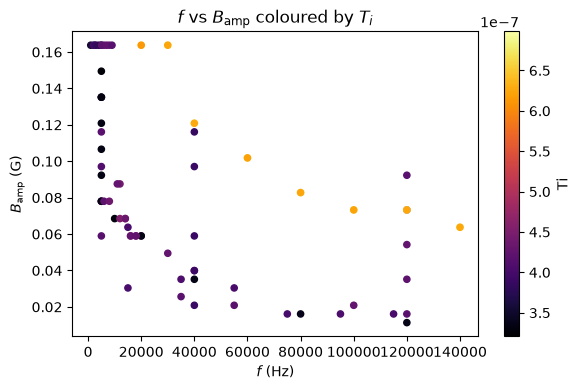

In [7]:
import matplotlib.pyplot as plt

# Create the scatter plot
scatter = results_df.plot.scatter(
    x='freq', 
    y='Bamp', 
    c='Ti', 
    cmap='inferno', 
    colorbar=True,   # Shows the color scale bar on the right
    figsize=(6, 4),
    sharex=False,     # Fixes a common matplotlib bug with x-axis labels
)

# Label the chart
scatter.set_title(r'$f$ vs $B_\mathrm{amp}$ coloured by $T_i$')
scatter.set_xlabel(r'$f$ (Hz)')
scatter.set_ylabel(r'$B_\mathrm{amp}$ (G)')

plt.tight_layout()  # Adjust subplots to fit into figure area.

plt.show()


In [8]:
# Get the top value and its total row count
most_common_freqs = results_df['freq'].value_counts()
# print(f"Frequency (Hz), # of runs: {most_common_freqs}")

### Checking amplitude scaling 
**Runs:** \
2024-03-26_B_UHfit.dat \
2024-03-26_C_UHfit.dat \
2024-04-03_F_UHfit.dat \
2024-04-05_C_UHfit.dat

C:\Users\colin\AppData\Local\Temp\ipykernel_7544\1672027000.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_filtered = df[df['freq'].isin(top_3_freqs)][df['heating_rate'] > 2*df['e_heating_rate']]
c:\Users\colin\Documents\GitHub\chip-lab\Fast-Modulation-Contact-Correlation-Project\analysis\unitary_fermi_gas.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  return (4*pi)/((3*pi**2)* eos_ufg(betamu))**(2/3)


Quadratic fits for each frequency:
-------------------------------------
Frequency: 5000.0 Hz, Fit slope: 3.0069 ± 0.4426, Intercept: 0.009033 ± 0.008349
0.5880134570987654 12210.925401234568 292.9299812814759
Frequency: 40000.0 Hz, Fit slope: 193.6127 ± 9.1854, Intercept: 0.186590 ± 0.041637
0.514678525 15753.34702727227 323.2660771177012
Frequency: 120000.0 Hz, Fit slope: 355.4521 ± 34.0034, Intercept: 0.213487 ± 0.032015
0.6058659 14568.66 323.2660771177012


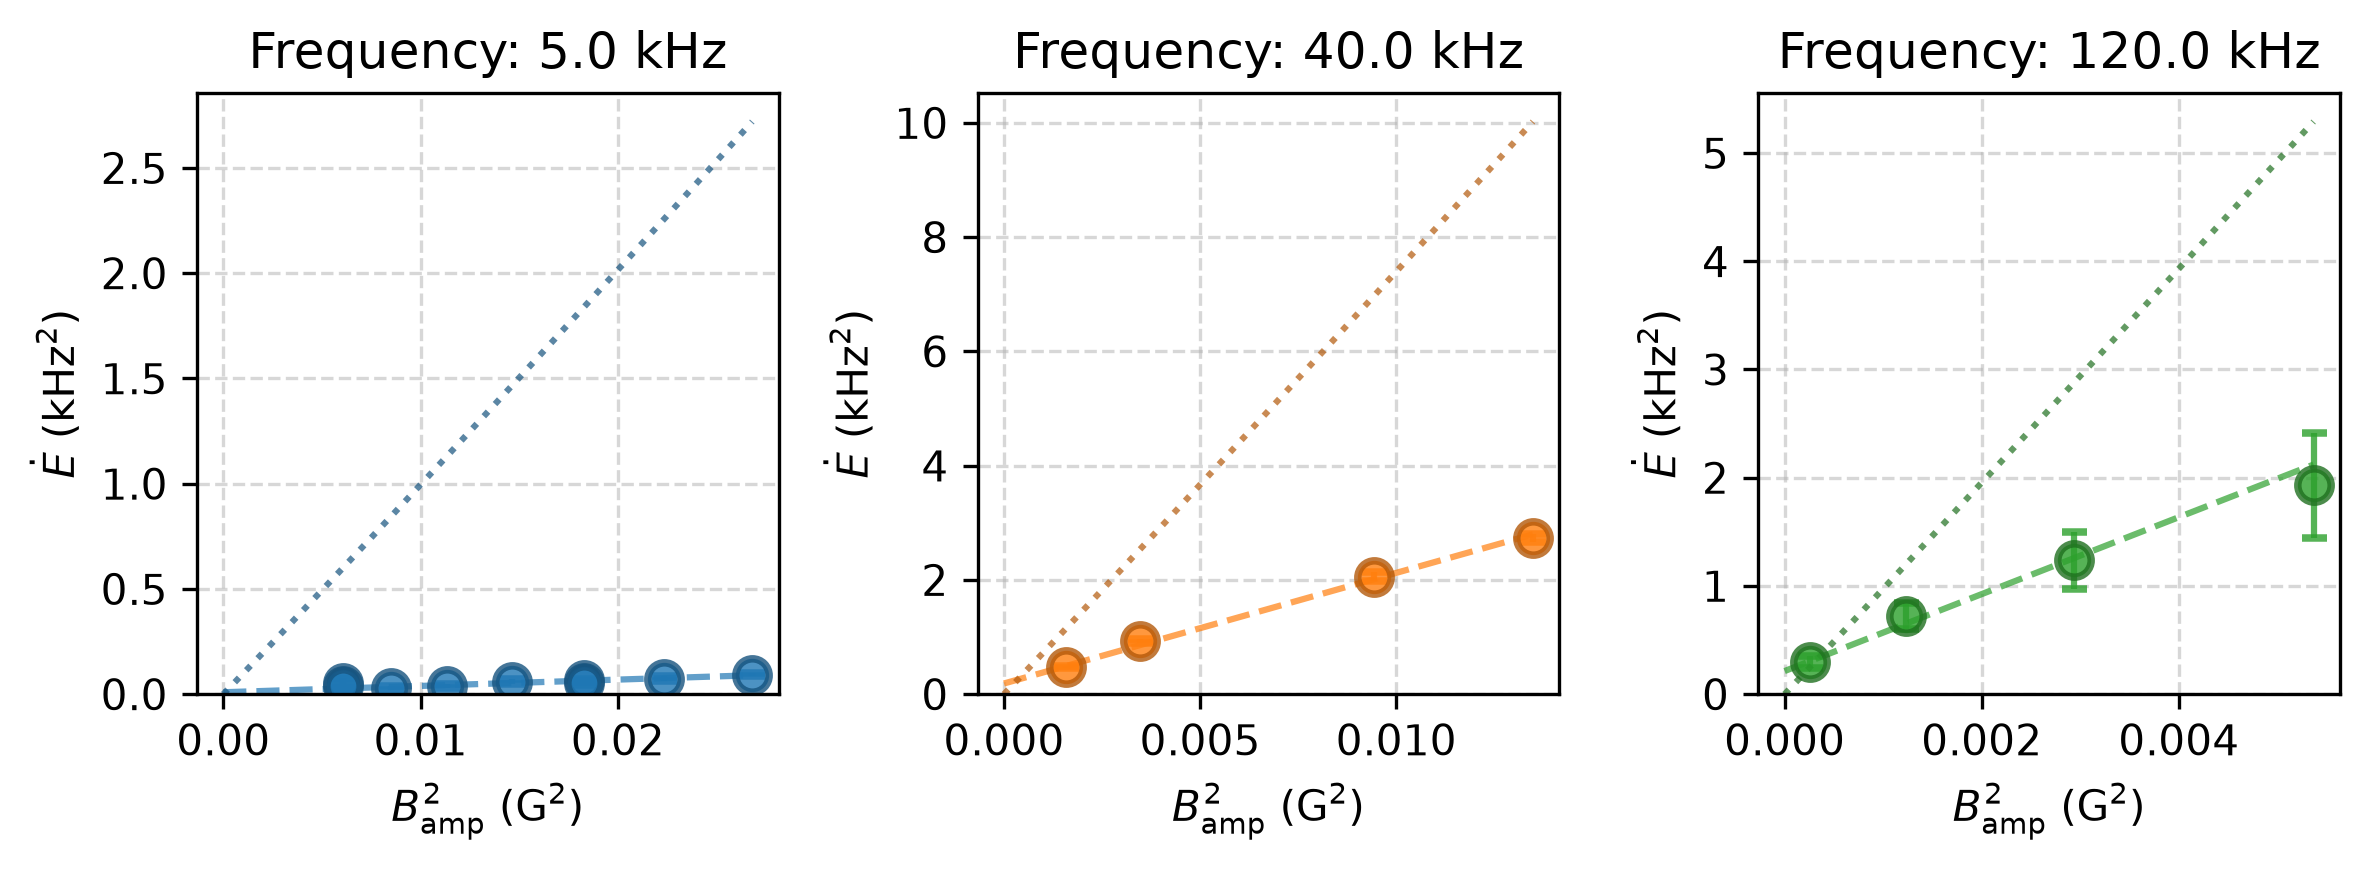

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

df = results_df.copy()

# Find the 3 most common frequencies
top_3_freqs = df['freq'].value_counts().nlargest(3).index

# Filter the DataFrame to keep only those 3 frequencies
df_filtered = df[df['freq'].isin(top_3_freqs)][df['heating_rate'] > 2*df['e_heating_rate']]

# These are datasets where the initial temperature is too different from most of the others
drop_index = [73, 12, 29, 2, 47, 55, 31, 51, 59, 26]
df_plot = df_filtered.drop(index=drop_index)

# Set font size back to default
plt.rcParams.update({'font.size': 10})

# Plot each frequency group individually to assign distinct colors
fig, axes = plt.subplots(1, 3, figsize=(8, 3), dpi=300)
axs = axes.flatten()  
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # High-contrast distinct colors

print("Quadratic fits for each frequency:")
print("-------------------------------------")

for i, freq_val in enumerate(top_3_freqs):
    # Filter data for just this specific frequency
    group = df_plot[df_plot['freq'] == freq_val].copy()
    trapped_gas_params = (group['ToTFi'].mean(), group['EFi'].mean(), group['barnu'].mean())

    # Calculate a 30% darker version of the base color
    rgb = mcolors.to_rgb(colors[i])
    dark_edge_color = [c * 0.7 for c in rgb]  # Multiply by 0.7 to dim it
    
    axs[i].errorbar(
        x=group['Bamp']**2,
        y=group['heating_rate']/1e6,    # kHz^2
        yerr=group['e_heating_rate']/1e6,
        fmt='o',                # 'none' completely hides the internal errorbar marker
        color=colors[i],
        markeredgecolor=dark_edge_color,  
        capsize=3,
        alpha=0.8, 
        markeredgewidth=1.8,
        markersize=8,                      # Controls marker size
        label=f'{freq_val} kHz'     # Add a label for the legend
    )

    popt, pcov = curve_fit(lambda x, m, b: m * x + b,
                            group['Bamp']**2, 
                            group['heating_rate']/1e6,  # kHz^2
                            sigma=group['e_heating_rate']/1e6
                           )
    perr = np.sqrt(np.diag(pcov))

    print(*trapped_gas_params)
    print(f"Frequency: {freq_val} Hz, Fit slope: {popt[0]:.4f} ± {perr[0]:.4f}, Intercept: {popt[1]:.6f} ± {perr[1]:.6f}")

    TUG = TrappedUnitaryGas(*trapped_gas_params)

    a_sqs = np.linspace(0, group['Bamp'].max()**2, 100)
    inv_as = inv_a_amp_from_Bamp(group['B'].mean(), np.sqrt(a_sqs))

    axs[i].plot(a_sqs, np.polyval(popt, a_sqs), color=colors[i], linestyle='--', alpha=0.7)
    axs[i].plot(a_sqs, np.array([TUG.calc_Edot(nu=freq_val, inv_a0=inv_a) for inv_a in inv_as])/1e6/TUG.Ns/2, 
                color=dark_edge_color, linestyle=':', alpha=0.7)


# Label the chart
for ax in axs:
    ax.set_title(f'Frequency: {top_3_freqs[axs.tolist().index(ax)]/1e3} kHz')
    ax.set_ylabel(r'$\dot{E}$ (kHz$^2$)')
    ax.set_xlabel(r'$B_\mathrm{amp}^2$ (G$^2$)')
    ax.grid(True, linestyle='--', alpha=0.5)
    # ax.legend(title='Frequencies', loc='lower right')
    _, top = ax.get_ylim()
    ax.set_ylim(bottom=0, top=top)

fig.tight_layout()  # Adjust subplots to fit into figure area.
plt.show()


In [ ]:
df_plot[['freq','amplitude','ToTFi','heating_rate','filename']].sort_values(by=['freq','amplitude'])
# df_plot['filename'].unique()

KeyError: "['Edot_theory'] not in index"

c:\Users\coldatoms\Documents\cjdGitHub\Fast-Modulation-Contact-Correlation-Project\analysis\unitary_fermi_gas.py:359: RuntimeWarning: invalid value encountered in scalar divide
  Edot_C = 9*pi*(self.T*betaomega)**2/(betaomega)**(3/2) * pifactors * self.Ctrap \
c:\Users\coldatoms\Documents\cjdGitHub\Fast-Modulation-Contact-Correlation-Project\analysis\unitary_fermi_gas.py:392: RuntimeWarning: invalid value encountered in divide
  self.zetaDrude = self.Edot_drude/self.A**2 * (self.lambda_T**2*self.kF**2)/(9*pi*nus**2*2*self.Ns)


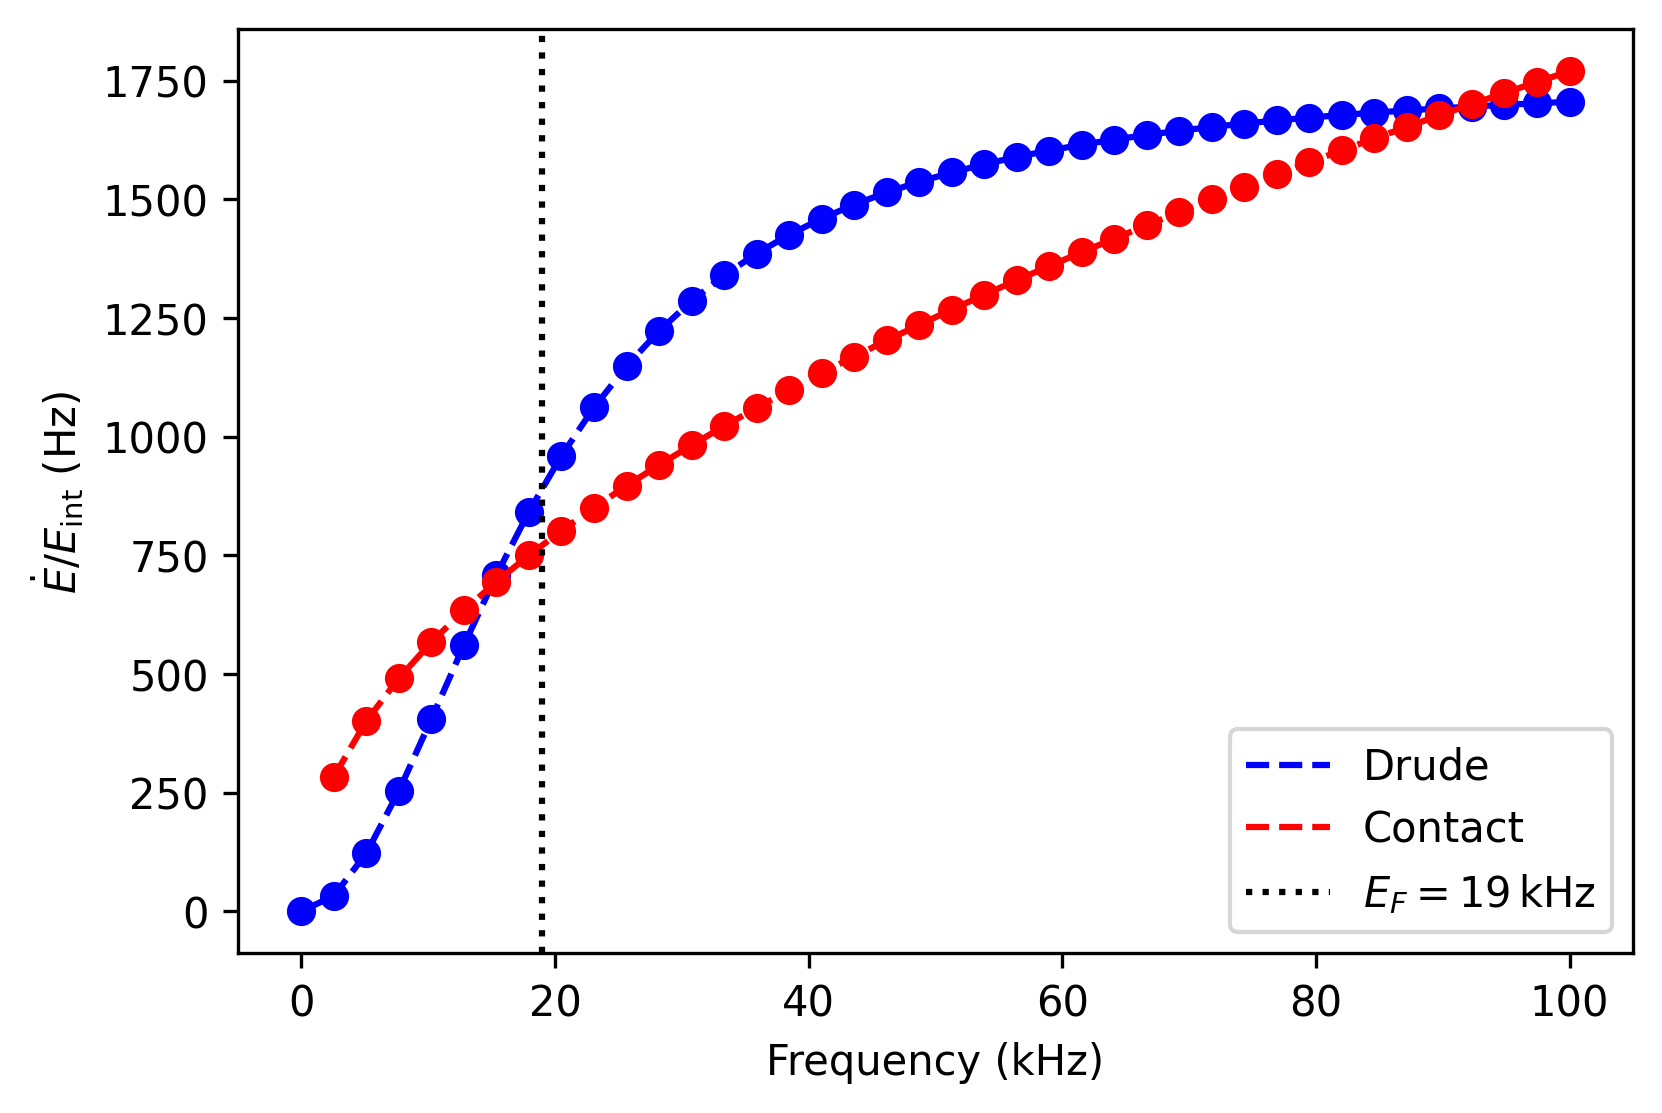

In [ ]:
ToTF = 0.58
EF = 19e3
barnu = 305

TUG = TrappedUnitaryGas(ToTF=ToTF, EF=EF, barnu=barnu)

TUG.modulate_field(np.linspace(0, 100e3, 40))

plt.figure(figsize=(6, 4), dpi=300)
plt.plot(TUG.nus/1e3, TUG.Edot_drude/TUG.Epot, 'b--', label='Drude')
plt.plot(TUG.nus/1e3, TUG.Edot_drude/TUG.Epot, 'o', color='b', markersize=6)

plt.plot(TUG.nus/1e3, TUG.Edot_contact/TUG.Epot, 'r--', label='Contact')
plt.plot(TUG.nus/1e3, TUG.Edot_contact/TUG.Epot, 'o', color='r', markersize=6)

plt.xlabel('Frequency (kHz)')
plt.ylabel(r'$\dot{E}/E_\mathrm{int}$ (Hz)')

plt.axvline(x=TUG.EF/1e3, color='k', linestyle=':', label=r'$E_F = 19\,$kHz')

plt.legend()

plt.savefig('figures/heating_rate_vs_frequency.pdf', dpi=300, bbox_inches='tight')

plt.show()